In [1]:
import sys
import numpy as np
import anndata as ad
import polars as pl
import src as scit

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cttag = ad.read_h5ad('private/data/clean_method/cttag_wt_inferred.h5ad')
mt = ad.read_h5ad('private/data/clean_method/mutant_inferred.h5ad')

In [3]:
active_meth = pl.read_csv('private/data/meth_active.csv', has_header=False)['column_1'].to_numpy()
muscle_up = pl.read_csv('private/muscle_meth_up.txt', has_header=False).to_numpy().ravel()
muscle_down = pl.read_csv('private/muscle_meth_down.txt', has_header=False).to_numpy().ravel()

In [4]:
cttag = cttag[cttag.obs['timep']=='14_16h'].copy()

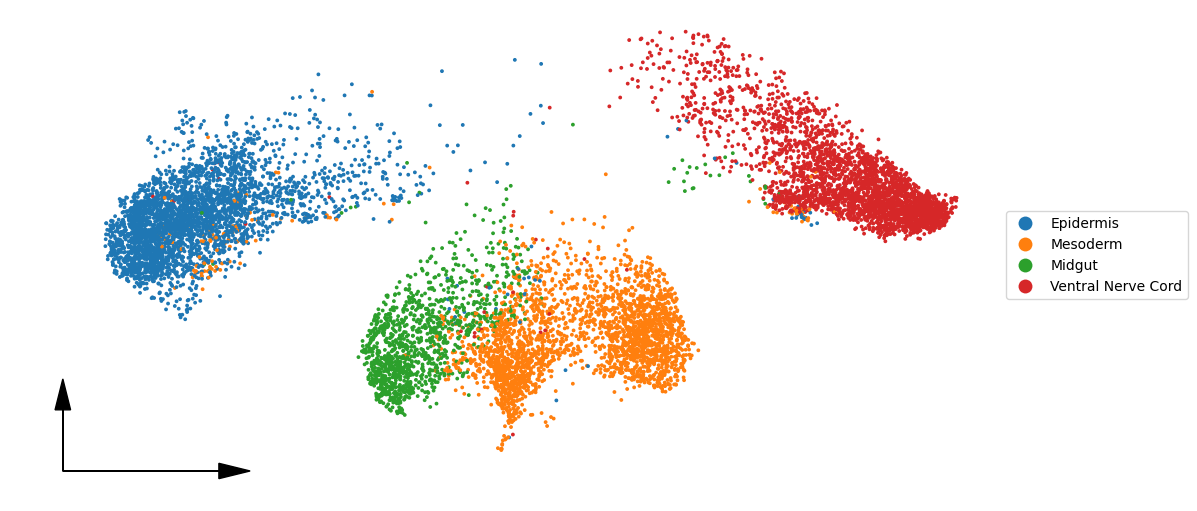

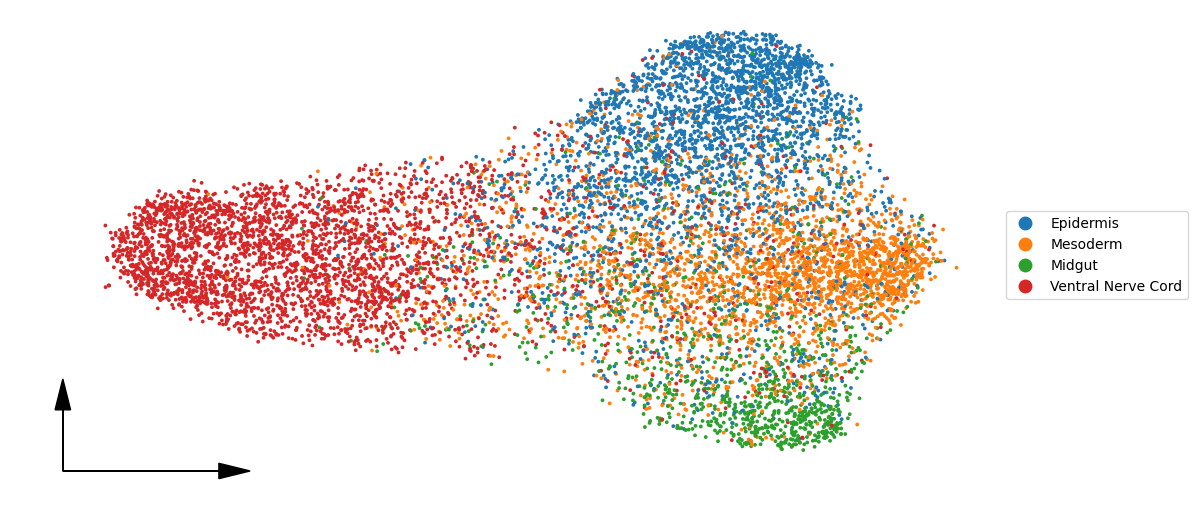

In [5]:
import pandas as pd
for adata in (cttag, mt):
    label_array = adata.obs['label'].to_numpy()

    mask_muscle = label_array == 'Muscle'
    mask_fat_body = label_array == 'Fat Body'
    label_array[mask_muscle+mask_fat_body] = 'Mesoderm'

    adata.obs['label'] = pd.Categorical(label_array)
    scit.pl.embedding2d(adata, 'X_umap', 'label')

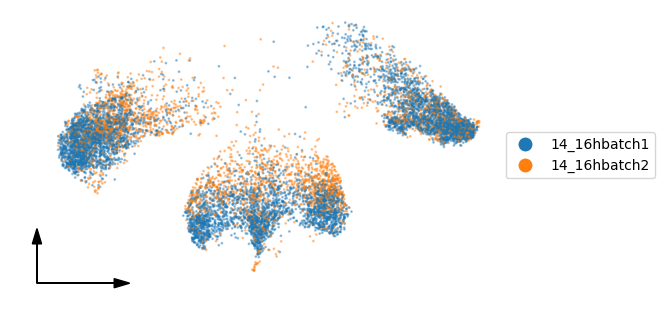

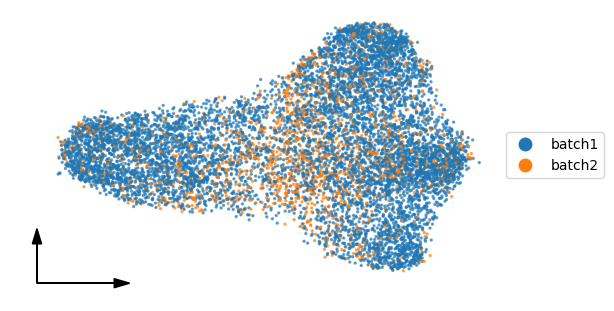

In [6]:
import pandas as pd
scit.set_defaults(figsize=(5,3))
cttag.obs['time_batch'] = pd.Categorical(cttag.obs['timep'].to_numpy() + cttag.obs['batch'].to_numpy())
scit.pl.embedding2d(cttag, 'X_umap', 'time_batch', size=1, alpha=0.4)
scit.pl.embedding2d(mt, 'X_umap', 'batch', size=2, alpha=0.6)

In [7]:
scit.set_defaults(figsize=(6,5))

lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=True,
    #log_transform=True,
    idf_transform=False,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=True,
    idf_transform=False,
    #log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)


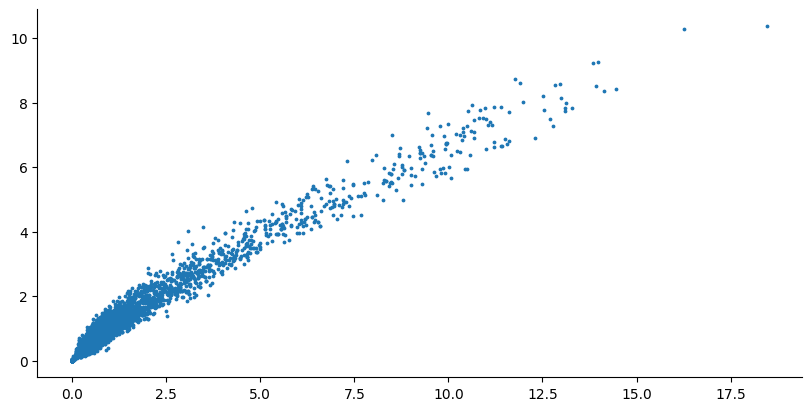

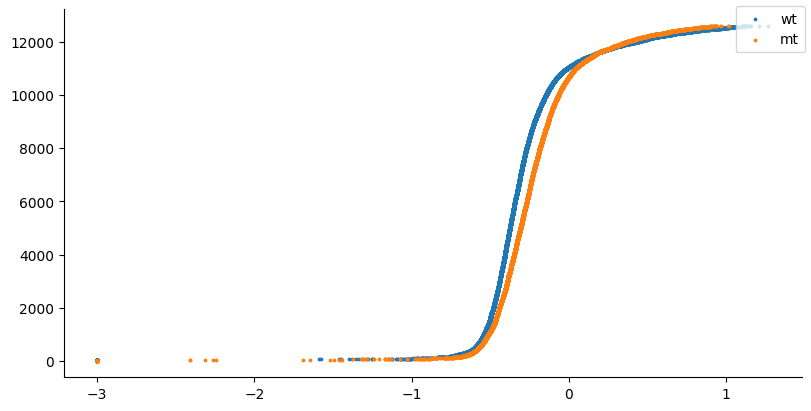

In [8]:
scit.set_defaults(figsize=(8,4))
import scipy.stats as sts
from src.plotting.int import scatter
from src.advanced.plotting._rank import rank_plot
from src.tools._layers import get_layer_feature_means, get_rank_scalars
wt_m = get_layer_feature_means(cttag, lc_meth)
mt_m = get_layer_feature_means(mt, lc_meth)

scatter(
        [
            np.c_[wt_m, mt_m],
        ]
    )

rank_plot(wt_m, mt_m, labels=['wt', 'mt'])

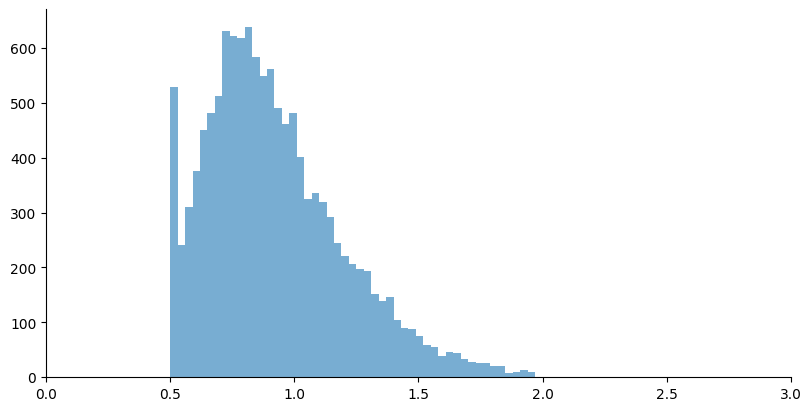

In [9]:

sclrs = get_rank_scalars(wt_m, mt_m)
scit.pl.int.histogram(sclrs, xminmax=(0,3))

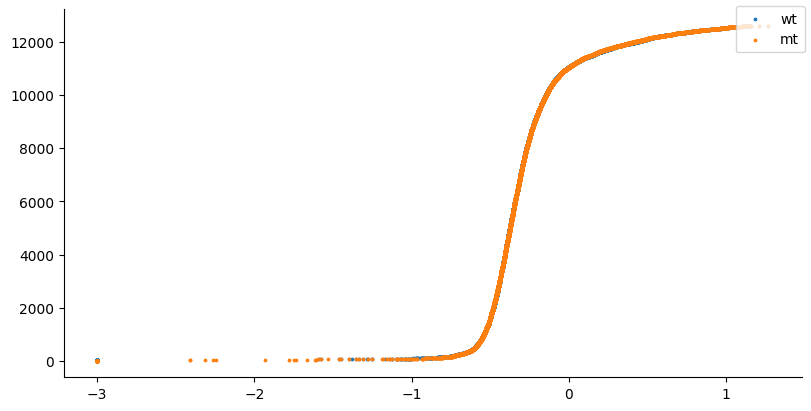

In [10]:
rank_plot(wt_m, mt_m*sclrs, labels=['wt', 'mt'])

In [11]:
cttag.obs['dummy']='me'
mt.obs['dummy']='me'
cttag.obs['dummy']=pd.Categorical(cttag.obs['dummy'])
mt.obs['dummy']=pd.Categorical(mt.obs['dummy'])

In [ ]:
scit.tl.layer_pick_features(cttag, lc_meth, active_meth)

meth_change = scit.tl.likelihood_test_on_adata(
    cttag,
    mt,
    'dummy',
    lc_meth
)

Info: Running likelihood test with minimum LFC=0.25; min_base_mean=None
Info: Running test on 535 features. Group 1 n=10111, group 2 n=10450
Debug: traced _likelihood_ratio_test_many
Debug: traced fit_log_regression
Debug: traced likelihood_ratio_test
Debug: traced fit_log_regression
Started batch
Finished batch


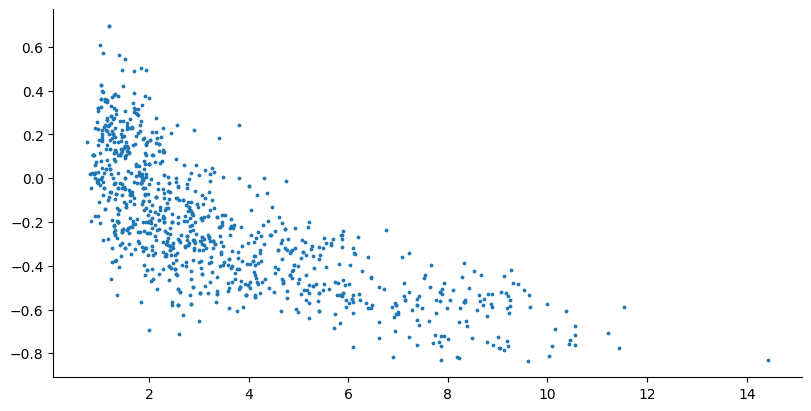

In [13]:
scit.pl.int.scatter(
    np.c_[meth_change['base_mean'].to_numpy(), meth_change['score'].to_numpy()]
)

In [14]:
scit.tl.layer_pick_features(cttag, lc_meth, active_meth)

meth_change = scit.tl.likelihood_test_on_adata(
    cttag,
    mt,
    'dummy',
    lc_meth,
    mean_ranks_normalize=True
)

Info: Running likelihood test with minimum LFC=0.25; min_base_mean=None
Info: Running test on 278 features. Group 1 n=10111, group 2 n=10450
Debug: traced _likelihood_ratio_test_many
Started batch
Finished batch


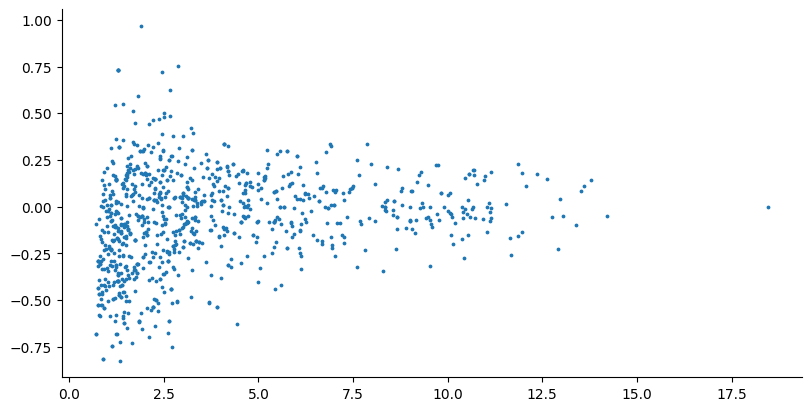

In [15]:
scit.pl.int.scatter(
    np.c_[meth_change['base_mean'].to_numpy(), meth_change['score'].to_numpy()]
)

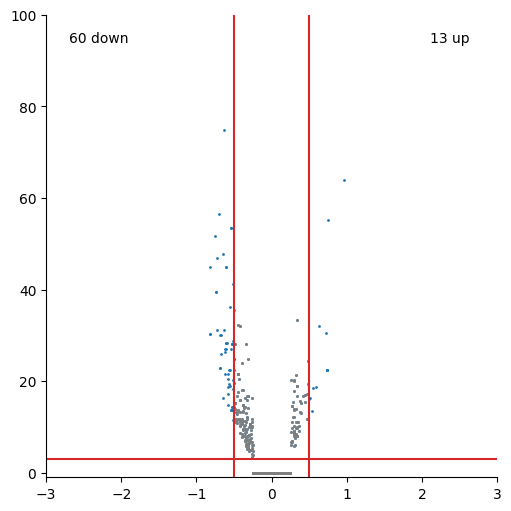

In [16]:

scit.set_defaults(figsize=(5,5))
from src.plotting._statistics import volcano_plot
volcano_plot(meth_change['pval'].to_numpy(), meth_change['score'].to_numpy(), yminmax=(-1,100), min_lfc=0.5)
